# Lab: Solving FrozenLake with Value Iteration

**Course:** PROG74040 — Advanced Topics in Artificial Intelligence and Machine Learning  
**Topic:** Model-Based Reinforcement Learning  

## Learning objectives

By the end of this lab, you should be able to:
1. Inspect the known transition model of a Gymnasium environment.
2. Connect `env.unwrapped.P` to the MDP quantities \(p(s',r\mid s,a)\).
3. Implement the Value Iteration algorithm.
4. Extract an optimal policy from the converged value function.
5. Explain how the discount factor and stochastic transitions affect the result.

> Value Iteration assumes that the environment model is known.

## 1. Install and import the required libraries

Run the installation cell in Google Colab. If Gymnasium is already installed, the command will finish quickly.

In [1]:
# Run this cell in Google Colab or Jupyter if Gymnasium is not installed.
%pip install -q gymnasium 

Note: you may need to restart the kernel to use updated packages.


In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 2. Create the FrozenLake environment

We use the standard $4\times4$ FrozenLake map.

- `S`: start
- `F`: frozen surface
- `H`: hole
- `G`: goal

When `is_slippery=True`, the action selected by the agent may not lead exactly in the intended direction. This makes the transition model stochastic.

States:
```text
 0(S)   1     2     3
 4      5(H)  6     7(H)
 8      9     10(H) 11
12(H)  13     14    15(G)
```

In [9]:
env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=False
)

print("Number of states:", env.observation_space.n)
print("Number of actions:", env.action_space.n)
print()
print("Map:")
print(env.unwrapped.desc.astype(str))

Number of states: 16
Number of actions: 4

Map:
[['S' 'F' 'F' 'F']
 ['F' 'H' 'F' 'H']
 ['F' 'F' 'F' 'H']
 ['H' 'F' 'F' 'G']]


### Question 1
How many states and actions are in this environment?

### Answer

There are:

- 16 states, because the map is $4\times4$.
- 4 actions:
  - `0`: Left
  - `1`: Down
  - `2`: Right
  - `3`: Up

## 3. Inspect the known transition model

For FrozenLake, Gymnasium exposes the full model through:

P[state][action] returns all possible outcomes after taking the selected action from the selected state.

```python
env.unwrapped.P[state][action]
```

Each returned tuple has the form:

```text
(probability, next_state, reward, terminated)
```

the correspondence is:

- `probability` $\rightarrow p(s',r\mid s,a)$, or more informally the probability of the listed transition.
- `next_state` $\rightarrow s'$.
- `reward` $\rightarrow r$.
- `terminated` indicates whether $s'$ is terminal.

Because the model lists every possible transition and its probability, this is a **known-model** or **model-based** setting.


For example, if the state=0, action =1
```text
Possible outcomes:
Left  → wall → state 0 → reward 0
Down         → state 4  → reward 0
Right        → state 1  → reward 0
```

In [10]:
state = 0
action = 1  # Down

transitions = env.unwrapped.P[state][action]

print(f"Transitions from state {state} after action {action}:")
for probability, next_state, reward, terminated in transitions:
    print(
        f"probability={probability:.3f}, " #a floating-point number with exactly 3 digits after the decimal point.
        f"next_state={next_state}, "
        f"reward={reward}, "
        f"terminated={terminated}"
    )

Transitions from state 0 after action 1:
probability=1.000, next_state=4, reward=0, terminated=False


### Question 2

What happens when you change `is_slippery=True` to `is_slippery=False`?  Does each state–action pair still have multiple possible next states?


### Answer
When `is_slippery=True`, FrozenLake is stochastic. The agent may move in the intended direction or slip to one of the neighboring directions. Therefore, one state–action pair can have multiple possible next states.

When `is_slippery=False`, the environment becomes deterministic. The agent always moves in the selected direction, unless a wall blocks the movement. Therefore, each state–action pair normally has only one possible next state, with probability=1. 

## 4. Compute one action value

For Value Iteration, the action value at iteration \(k\) is:

$ Q_k(s,a) = \sum_{s',r} p(s',r\mid s,a) \left[r+\gamma V_k(s')\right]$

For a terminal transition, there is no future value after termination, so we use:

$r+\gamma\cdot 0$


In [11]:
def calculate_action_value(env, state, action, V, gamma):
    """Calculate Q_k(s, a) from the known transition model."""
    action_value = 0.0

    for probability, next_state, reward, terminated in env.unwrapped.P[state][action]:
        future_value = 0.0 if terminated else V[next_state]

        action_value += probability * (reward + gamma * future_value)

    return action_value

Below code calculates the Q-value of every possible action at $state 0$, using an initial state-value table where all values are zero.

In [12]:
n_states = env.observation_space.n #total number of states = 16
n_actions = env.action_space.n #total number of actions = 4

V = np.zeros(n_states)
gamma = 0.9

state = 0

print(f"Action values at state {state}, using the initial V(s)=0:")
for action in range(n_actions):
    q_value = calculate_action_value(
        env=env,
        state=state,
        action=action,
        V=V,
        gamma=gamma
    )
    print(f"Action {action}: Q({state}, {action}) = {q_value:.3f}")

Action values at state 0, using the initial V(s)=0:
Action 0: Q(0, 0) = 0.000
Action 1: Q(0, 1) = 0.000
Action 2: Q(0, 2) = 0.000
Action 3: Q(0, 3) = 0.000


### Question 3

Why are many action values initially equal to zero?

### Answer
Initially:
$V_0(s)=0$

for all states.

Most transitions also give immediate reward $0$. Therefore:

$r+\gamma V_0(s')=0+\gamma(0)=0$

Only transitions that immediately enter the goal can produce a positive value during the first iteration.

## 5. Perform one full Bellman optimality update

For each state:

$ V_{k+1}(s) = \max_a Q_k(s,a)$

The function below performs one complete sweep over all states.

In [13]:
def one_value_iteration_sweep(env, V, gamma):
    """Perform one synchronous Value Iteration sweep."""
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    new_V = np.zeros(n_states)

    for state in range(n_states):
        action_values = [
            calculate_action_value(
                env=env,
                state=state,
                action=action,
                V=V,
                gamma=gamma
            )
            for action in range(n_actions)
        ]

        new_V[state] = max(action_values)

    return new_V

In [14]:
V0 = np.zeros(n_states)
V1 = one_value_iteration_sweep(env, V0, gamma=0.9)

print("V0:")
print(V0.reshape(4, 4))
print()
print("V1 after one full sweep:")
print(V1.reshape(4, 4))

V0:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

V1 after one full sweep:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 1. 0.]]


### Question 4

Which states become positive first?

### Answer

States that can reach the goal in one transition become positive first.

The goal reward first affects states near the goal. In later sweeps, those updated values affect states farther away. This is how value information gradually propagates through the state space.

## 6. Implement complete Value Iteration

We repeatedly apply the Bellman optimality update until the largest change is below a threshold:

$\Delta=\max_{s\in\mathcal S}\left|V_{k+1}(s)-V_k(s)\right|$

We stop when:
$\Delta < \theta$

In [15]:
def value_iteration(
    env,
    gamma=0.9,
    threshold=1e-8,
    max_iterations=10_000,
    verbose=False
):
    """Run synchronous Value Iteration until convergence."""
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    V = np.zeros(n_states)
    deltas = []

    for iteration in range(max_iterations):
        new_V = np.zeros(n_states)

        for state in range(n_states):
            action_values = []

            for action in range(n_actions):
                q_value = calculate_action_value(
                    env=env,
                    state=state,
                    action=action,
                    V=V,
                    gamma=gamma
                )
                action_values.append(q_value)

            new_V[state] = max(action_values)

        delta = np.max(np.abs(new_V - V))
        deltas.append(delta)
        V = new_V

        if verbose and (iteration < 10 or (iteration + 1) % 50 == 0):
            print(
                f"Iteration {iteration + 1:4d} | "
                f"delta = {delta:.10f}"
            )

        if delta < threshold:
            return V, iteration + 1, deltas

    raise RuntimeError(
        "Value Iteration did not converge within max_iterations."
    )

In [16]:
optimal_values, iterations, deltas = value_iteration(
    env,
    gamma=0.9,
    threshold=1e-8,
    verbose=True
)

print()
print(f"Converged after {iterations} iterations.")
print()
print("Optimal state values:")
print(optimal_values.reshape(4, 4))

Iteration    1 | delta = 1.0000000000
Iteration    2 | delta = 0.9000000000
Iteration    3 | delta = 0.8100000000
Iteration    4 | delta = 0.7290000000
Iteration    5 | delta = 0.6561000000
Iteration    6 | delta = 0.5904900000
Iteration    7 | delta = 0.0000000000

Converged after 7 iterations.

Optimal state values:
[[0.59  0.656 0.729 0.656]
 [0.656 0.    0.81  0.   ]
 [0.729 0.81  0.9   0.   ]
 [0.    0.9   1.    0.   ]]


### Question 5

Why do we use the maximum change across all states?

### Answer

We need every state value to become stable.

If we only checked the average change, large positive and negative changes could partially cancel each other. Using
$\max_s |V_{k+1}(s)-V_k(s)|$

ensures that no state is still changing by more than the threshold.

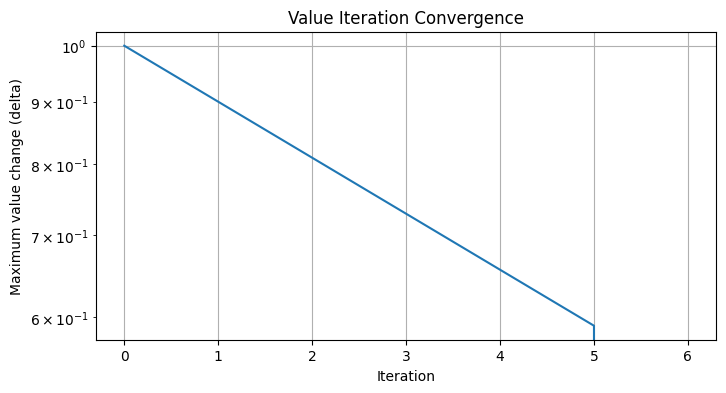

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(deltas)
plt.xlabel("Iteration")
plt.ylabel("Maximum value change (delta)")
plt.title("Value Iteration Convergence")
plt.yscale("log")
plt.grid(True)
plt.show()

### Question 6

What should happen to $\Delta$ as the algorithm converges?

### Answer

$\Delta$ should decrease toward zero.

This means that another Bellman update produces almost no change, so the value function is approaching a fixed point of the Bellman optimality operator.

## 7. Extract the optimal policy

After Value Iteration converges, choose the action with the largest action value:

$\pi^*(s)\in\arg\max_a Q^*(s,a)$

The policy does not need a separate iterative update inside the Value Iteration loop. It can be extracted after the values converge.

In [18]:
def extract_policy(env, V, gamma=0.9):
    """Extract a greedy policy from a value function."""
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    policy = np.zeros(n_states, dtype=int)
    q_table = np.zeros((n_states, n_actions))

    for state in range(n_states):
        for action in range(n_actions):
            q_table[state, action] = calculate_action_value(
                env=env,
                state=state,
                action=action,
                V=V,
                gamma=gamma
            )

        policy[state] = int(np.argmax(q_table[state]))

    return policy, q_table

In [19]:
optimal_policy, model_based_q_table = extract_policy(
    env,
    optimal_values,
    gamma=0.9
)

print("Optimal action numbers:")
print(optimal_policy.reshape(4, 4))
print()
print("Q-values calculated from the converged state values:")
print(model_based_q_table)

Optimal action numbers:
[[1 2 1 0]
 [1 0 1 0]
 [2 1 1 0]
 [0 2 2 0]]

Q-values calculated from the converged state values:
[[0.531 0.59  0.59  0.531]
 [0.531 0.    0.656 0.59 ]
 [0.59  0.729 0.59  0.656]
 [0.656 0.    0.59  0.59 ]
 [0.59  0.656 0.    0.531]
 [0.    0.    0.    0.   ]
 [0.    0.81  0.    0.656]
 [0.    0.    0.    0.   ]
 [0.656 0.    0.729 0.59 ]
 [0.656 0.81  0.81  0.   ]
 [0.729 0.9   0.    0.729]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.81  0.9   0.729]
 [0.81  0.9   1.    0.81 ]
 [0.    0.    0.    0.   ]]


In [20]:
ACTION_SYMBOLS = {
    0: "←",
    1: "↓",
    2: "→",
    3: "↑"
}

def policy_to_symbols(policy, shape=(4, 4)):
    return np.array(
        [ACTION_SYMBOLS[int(action)] for action in policy]
    ).reshape(shape)

print("Optimal policy:")
print(policy_to_symbols(optimal_policy))

Optimal policy:
[['↓' '→' '↓' '←']
 ['↓' '←' '↓' '←']
 ['→' '↓' '↓' '←']
 ['←' '→' '→' '←']]


### Question 7

What does `np.argmax` return?

### Answer

It returns the index of the first largest value.

Because action numbers are used as column indices, the returned index is also the selected action.

If multiple actions tie, `np.argmax` chooses the first one. Therefore, another equally optimal policy may exist even if it is not displayed.

## 8. Test the policy in the environment

Planning computes the policy from the known model. We can then evaluate that policy by running episodes.

In [21]:
def evaluate_policy(env, policy, episodes=1_000, max_steps=100, seed=42):
    successes = 0
    episode_returns = []
    episode_steps = []

    for episode in range(episodes):
        state, info = env.reset(seed=seed + episode)
        total_reward = 0.0

        for step in range(max_steps):
            action = int(policy[state])

            next_state, reward, terminated, truncated, info = env.step(action)

            total_reward += reward
            state = next_state

            if terminated or truncated:
                episode_steps.append(step + 1)
                break
        else:
            episode_steps.append(max_steps)

        episode_returns.append(total_reward)
        successes += int(total_reward > 0)

    return {
        "success_rate": successes / episodes,
        "mean_return": float(np.mean(episode_returns)),
        "mean_steps": float(np.mean(episode_steps))
    }

In [22]:
results = evaluate_policy(
    env,
    optimal_policy,
    episodes=1_000
)

print(f"Success rate: {results['success_rate']:.1%}")
print(f"Mean return:  {results['mean_return']:.3f}")
print(f"Mean steps:   {results['mean_steps']:.2f}")

Success rate: 100.0%
Mean return:  1.000
Mean steps:   6.00


### Question 9

Why might the success rate be below \(100\%\), even though the policy is optimal?

### Answer

Because the environment is slippery and stochastic.

An optimal policy maximizes expected return, but it cannot eliminate randomness from the environment. The intended action may still lead to an undesirable next state.